### Operacijska istraživanja  
### Prva laboratorijska vježba

**Lorena Jakić, 0036538677**

---


Dvorište prodajnog salona za automobile Braća Brzić može primiti do 50 automobila. Nabavna cijena FIAT Una je 5000, Tempre 6000, a Brave 7000 EUR. Ako salon naruči barem 40 automobila, dobiva rabat i to: na Una 6%, Tempru 8% i na Bravu 10%. Salon raspolaže sa 250000 EUR za nabavku automobila. Planirajte nabavu koja donosi najveći rabat.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pulp import *

### Primal

### Funkcija cilja

Salon dobiva rabat samo ako naruči **barem 40 automobila**:
- Uno: 6%
- Tempra: 8%
- Bravo: 10%

Maksimiziramo:

$$
Z = (5000 \cdot 0.06) x_1 + (6000 \cdot 0.08) x_2 + (7000 \cdot 0.10) x_3
$$

odnosno:

$$
Z = 300x_1 + 480x_2 + 700x_3
$$



### Ograničenja

1. **Kapacitet dvorišta**

$$
x_1 + x_2 + x_3 \le 50
$$

2. **Budžet**

$$
5000x_1 + 6000x_2 + 7000x_3 \le 250000
$$

3. **Minimalna narudžba za rabat**

$$
x_1 + x_2 + x_3 \ge 40
$$

$$
- x_1 - x_2 - x_3 \le -40
$$

4. **Nenegativnost**

$$
x_1, x_2, x_3 \ge 0
$$



### Model

$$
\begin{aligned}
\text{Maksimizirati:}\quad 
& Z = 300x_1 + 480x_2 + 700x_3 \\
\text{uz ograničenja:}\quad  
& x_1 + x_2 + x_3 \le 50 \\
& 5000x_1 + 6000x_2 + 7000x_3 \le 250000 \\
& -x_1 - x_2 - x_3 \le -40 \\
& x_1, x_2, x_3 \ge 0
\end{aligned}
$$


In [2]:
problem = LpProblem("nabava_automobila", LpMaximize)

x1 = LpVariable('x1', lowBound=0)
x2 = LpVariable('x2', lowBound=0)
x3 = LpVariable('x3', lowBound=0)


problem += (5000 * 0.06 * x1) + (6000 * 0.08 * x2) + (7000 * 0.10 * x3)
problem += (5000 * x1) + (6000 * x2) + (7000 * x3) <= 250000
problem += -x1 - x2 - x3 <= -40
problem += x1 + x2 + x3 <= 50

problem.solve(PULP_CBC_CMD(msg=False))

print(f"x1 (Una)   = {x1.varValue:.2f}")
print(f"x2 (Tempra)= {x2.varValue:.2f}")
print(f"x3 (Brava) = {x3.varValue:.2f}")
print(f"Maksimalan rabat = {value(problem.objective):.2f} EUR")


x1 (Una)   = 15.00
x2 (Tempra)= 0.00
x3 (Brava) = 25.00
Maksimalan rabat = 22000.00 EUR


- Ukupno auta: 40
- Maksimalan rabat: 22 000 EUR  
- Optimalna strategija za maksimalni rabat je kupiti 15 FIAT Una i 25 FIAT Brava.
Minimalni broj auta (40) je upravo dostignut. Kapacitet dvorišta (50) nije potpuno iskorišten jer je ukupno 40 auta, a maksimum je 50. Budžet je potpuno iskorišten.

- Optimalna strategija je kupiti kombinaciju Una i Brava koja maksimizira rabat uz zadovoljavanje ograničenja. Tempra nije uključena jer nema prednost ni u cijeni (skupija od Una) ni u omjeru rabata (lošiji od Brave).


Riješili smo kontinuirani problem (bez cjelobrojnog ograničenja) kako bismo vidjeli jesu li vrijednosti varijabli cijeli brojevi. Ako nisu, potrebno je dodatno riješiti problem kao cjelobrojni, ali to nije potrebno u ovom slučaju jer je rješenje cjelobrojno.

### Dual

**Minimizirati:**
$$
W = 50\,y_1 + 250000\,y_2 - 40\,y_3
$$

**uz ograničenja:**
$$
\begin{aligned}
y_1 + 5000\,y_2 - y_3 &\ge 300 \quad \\
y_1 + 6000\,y_2 - y_3 &\ge 480 \quad \\
y_1 + 7000\,y_2 - y_3 &\ge 700 \quad \\
y_1,\,y_2,\,y_3 &\ge 0.
\end{aligned}
$$


In [3]:
dual = LpProblem("dual_nabava_automobila", LpMinimize)

y1 = LpVariable("y1", lowBound=0)
y2 = LpVariable("y2", lowBound=0)
y3 = LpVariable("y3", lowBound=0)

dual += 50*y1 + 250000*y2 - 40*y3
dual += y1 + 5000*y2 - y3 >= 300
dual += y1 + 6000*y2 - y3 >= 480
dual += y1 + 7000*y2 - y3 >= 700

dual.solve(PULP_CBC_CMD(msg=False))

print(f"y1 = {y1.varValue:.4f}")
print(f"y2 = {y2.varValue:.4f}")
print(f"y3 = {y3.varValue:.4f}")
print(f"Minimalna vrijednost cilja duala = {value(dual.objective):.2f}")


y1 = 0.0000
y2 = 0.2000
y3 = 700.0000
Minimalna vrijednost cilja duala = 22000.00


- y1 = 0.0000: Kapacitet dvorišta (50) nije ograničavajući resurs jer je kupljeno 40 automobila, a može stati 50. Ako bi dobili još 1 mjesto više, to ne bi promijenilo rabat.
- y2 = 0.2000: Ako bi salon imao 1 € više budžeta, maksimalan rabat bi porastao za približno 0.20 € jer je budžet potpuno iskorišten.
- y3 = 700.0000: Ako bi morali kupiti 1 auto više od minimalna 40, maksimalan rabat bi pao za 700 €.

### Grafička metoda

Za grafičko rješavanje problema s tri varijable, koristimo 2D projekciju jer je x2=0. To bi značilo da bi optimalno područje u 3D prikazu bilo ravnina gdje je x2=0.

Optimalna točka je označena crnom bojom.


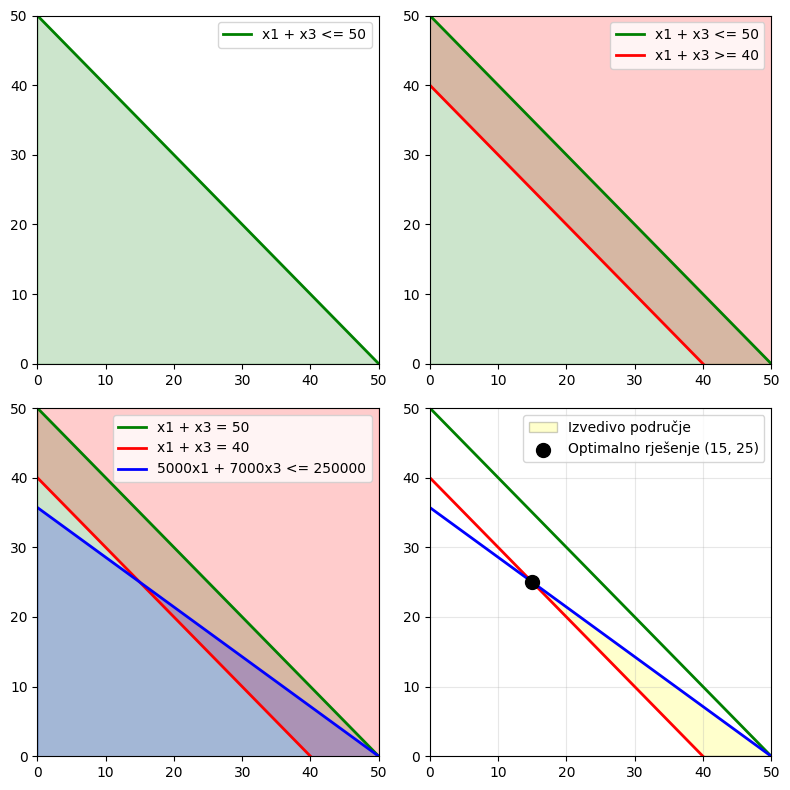

In [ ]:
x = np.linspace(0, 50, 400)

y1 = 50 - x
y2 = 40 - x
y3 = (250000 - 5000*x) / 7000 
y3 = np.maximum(y3, 0)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

ax = axes[0, 0]
ax.plot(x, y1, color='green', linewidth=2, label="x1 + x3 <= 50")
ax.fill_between(x, 0, y1, alpha=0.2, color='green')
ax.set_xlim(0, 50); ax.set_ylim(0, 50)
ax.legend()

ax = axes[0, 1]
ax.plot(x, y1, color='green', linewidth=2, label="x1 + x3 <= 50")
ax.plot(x, y2, color='red', linewidth=2, label="x1 + x3 >= 40")
ax.fill_between(x, 0, y1, alpha=0.2, color='green')
ax.fill_between(x, y2, 55, alpha=0.2, color='red')
ax.set_xlim(0, 50); ax.set_ylim(0, 50)
ax.legend()

ax = axes[1, 0]
ax.plot(x, y1, color='green', linewidth=2, label="x1 + x3 = 50")
ax.plot(x, y2, color='red', linewidth=2, label="x1 + x3 = 40")
ax.plot(x, y3, color='blue', linewidth=2, label="5000x1 + 7000x3 <= 250000")
ax.fill_between(x, 0, y1, alpha=0.2, color='green')
ax.fill_between(x, y2, 55, alpha=0.2, color='red')
ax.fill_between(x, 0, y3,alpha=0.2, color='blue')
ax.set_xlim(0, 50); ax.set_ylim(0, 50)
ax.legend()

ax = axes[1, 1]
ax.plot(x, y1, color='green', linewidth=2)
ax.plot(x, y2, color='red', linewidth=2)
ax.plot(x, y3, color='blue', linewidth=2)

points = np.array([[40, 0], [50, 0], [15, 25]])
ax.fill(points[:, 0], points[:, 1], alpha=0.2, color='yellow', label='Izvedivo područje', edgecolor='black')

ax.scatter([15], [25], color='black', s=100, zorder=5, label='Optimalno rješenje (15, 25)')

ax.set_xlim(0, 50); ax.set_ylim(0, 50)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
